# Sheath-cell power comparison across protocols and timepoints

Consolidates the notochordal sheath-cell numbers behind the protocol decision:
**does the newer dissociation protocol (v3.1.0 / GENE runs) or the older one
(v2.3.0, best represented by GAP16) give better power at 24/30/36 hpf?**

All values are recomputed from the cached count tables by `sheath_power_summary.py` —
nothing is hardcoded from a previous session.

**Model.** Power is analytic for the same inference model used in the analysis
notebooks: an offset negative-binomial GLM contrasting two arms, where the
variance of the log rate is approximately `(1/mu + 1/theta)` per arm. `mu` is the
expected *raw* sheath count per embryo (depth x abundance) and `theta` is the NB
dispersion, fit by method of moments.

**Depth is standardized.** Sequencing depth is a choice made at library prep, not a
property of the biology, so every power projection is computed at a common
`STD_DEPTH` (default 3000 cells/embryo, tunable in the setup cell). Concretely,
`mu = observed_per_1000_rate x STD_DEPTH`. Dispersion `theta` is the between-embryo
CV of the *rate* and is depth-invariant, so it is held at its observed value. This
isolates what actually differs between datasets -- sheath abundance and
embryo-to-embryo variability -- from how deep each happened to be sequenced.

**Two caveats that apply throughout.**

1. `theta = inf` means the observed variance fell *below* Poisson — a small-sample
   artifact, not infinite precision. Those groups are drawn hollow and their power
   figures are optimistic ceilings.
2. The control-only GENE extracts are small (GENE7 n=12, GENE11 n=7 at 36 hpf), so
   their `theta` is noisy. The qualitative
   ordering is trustworthy; the exact power values are not precise.

In [1]:
import sys, math
import statistics as s

sys.path.insert(0, ".")
import sheath_power_summary as sp

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ---- tunable knobs -------------------------------------------------------
STD_DEPTH = 3000     # cells/embryo; power is compared at this common depth
N_ARM     = 24       # per-arm sample size for the headline projections
EFFECT    = 0.40     # headline fractional reduction
# --------------------------------------------------------------------------

groups = sp.collect_groups()
records = sp.summarize(groups, standard_depth=STD_DEPTH)
print(f"{len(records)} dataset/timepoint groups loaded; standardized to {STD_DEPTH} cells/embryo")

PANEL = sp.PANEL_HPF

# Protocol grouping drives colour throughout.
OLD = {"v2.3.0", "GAP16 (v2.3.0)", "GENE11 ctrl (old)"}
def protocol(name):
    return "old method" if name in OLD else "new method"

COL_OLD, COL_NEW = "#C1666B", "#4281A4"
def colour(name):
    return COL_OLD if protocol(name).startswith("old") else COL_NEW

# Highlight the two configurations the decision actually rests on.
FOCUS = {"GAP16 (v2.3.0)", "GENE7 28C ctrl", "GENE11 ctrl (old)"}

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

14 dataset/timepoint groups loaded; standardized to 3000 cells/embryo


## 1. The two ingredients of power

Power is driven by the expected sheath count **at the standardized depth** (left,
= per-1,000 rate x STD_DEPTH) and by the **dispersion** `theta` (right). Both are
now depth-neutral, so a dataset that only looked good because it was sequenced deep
no longer does.

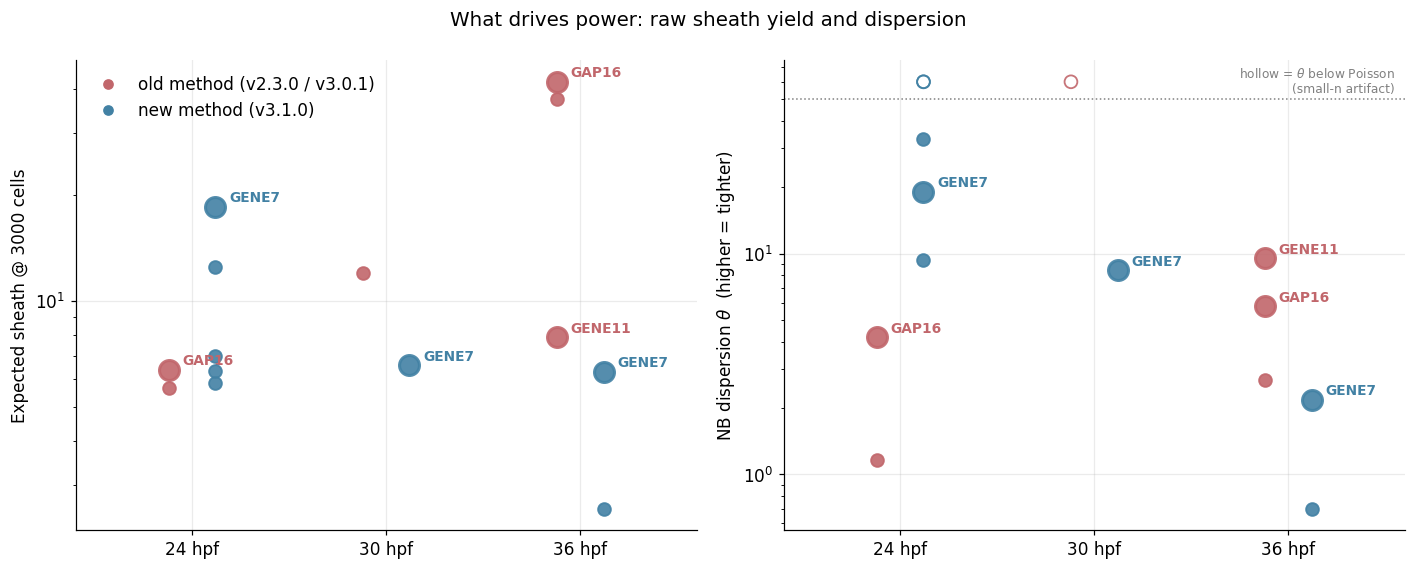

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, key, label, logy in [
    (axes[0], "std_expected_sheath", f"Expected sheath @ {STD_DEPTH} cells", True),
    (axes[1], "theta", "NB dispersion $\\theta$  (higher = tighter)", True),
]:
    for r in records:
        x = PANEL.index(r["hpf"]) + (0.12 if protocol(r["dataset"]).startswith("new") else -0.12)
        val = r[key]
        ceiling = key == "theta" and r["theta_is_ceiling"]
        if ceiling:
            val = 60  # draw off-scale ceiling markers at a fixed height
        ax.scatter(x, val, s=170 if r["dataset"] in FOCUS else 70,
                   facecolor="none" if ceiling else colour(r["dataset"]),
                   edgecolor=colour(r["dataset"]),
                   linewidth=2.0 if r["dataset"] in FOCUS else 1.2,
                   zorder=3, alpha=0.9)
        if r["dataset"] in FOCUS:
            ax.annotate(r["dataset"].split()[0], (x, val), textcoords="offset points",
                        xytext=(9, 3), fontsize=9, color=colour(r["dataset"]), weight="bold")
    ax.set_xticks(range(len(PANEL)))
    ax.set_xticklabels([f"{h} hpf" for h in PANEL])
    ax.set_xlim(-0.6, len(PANEL) - 0.4)
    if logy:
        ax.set_yscale("log")
    ax.set_ylabel(label)

axes[1].axhline(50, ls=":", c="grey", lw=1)
axes[1].text(len(PANEL) - 0.45, 52, "hollow = $\\theta$ below Poisson\n(small-n artifact)",
             fontsize=8, ha="right", va="bottom", color="grey")

handles = [Line2D([], [], marker="o", ls="", color=COL_OLD, label="old method (v2.3.0 / v3.0.1)"),
           Line2D([], [], marker="o", ls="", color=COL_NEW, label="new method (v3.1.0)")]
axes[0].legend(handles=handles, frameon=False, loc="upper left")
fig.suptitle("What drives power: raw sheath yield and dispersion", y=0.99, fontsize=13)
fig.tight_layout()
plt.show()

## 2. The protocol crossover

The clearest single view. Old-protocol sheath yield **rises** with age, tracking a
population that is genuinely proliferating. New-protocol yield **falls** — consistent
with progressively worse recovery of notochord cells as they stiffen and resist
mechanical dissociation.

Sequencing depth is comparable between GAP16 and GENE7 at 36 hpf (~3.7k vs ~3.9k
median cells), so this is not a depth artifact.

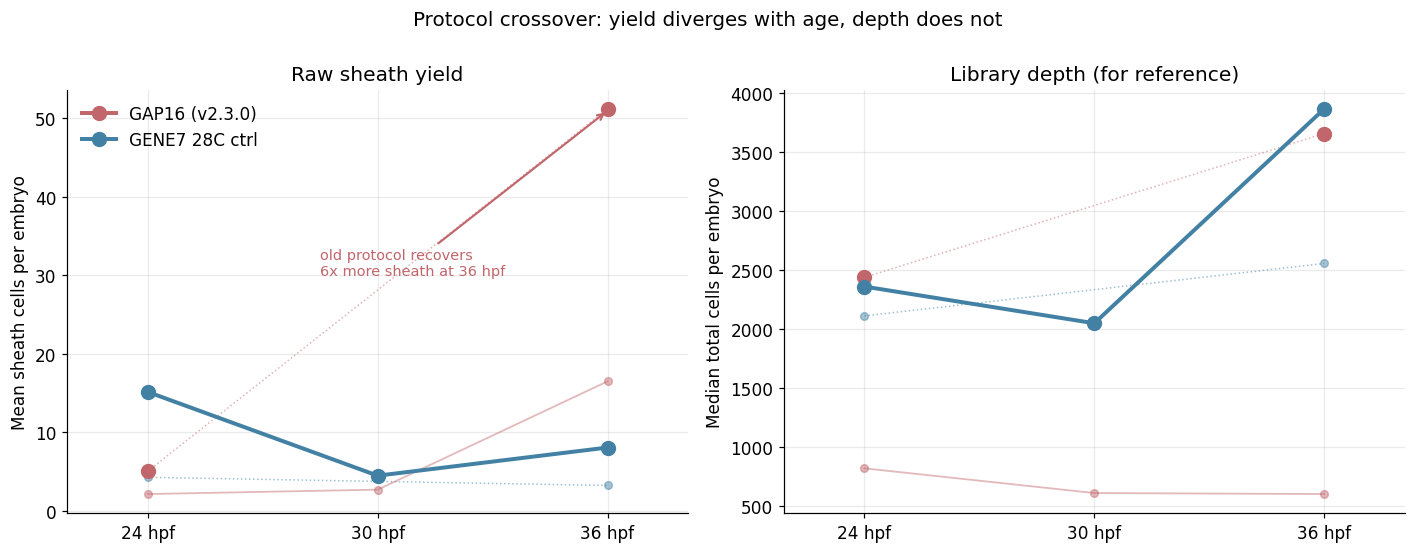

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylab, title in [
    (axes[0], "mean_sheath", "Mean sheath cells per embryo", "Raw sheath yield"),
    (axes[1], "median_depth", "Median total cells per embryo", "Library depth (for reference)"),
]:
    for name in sorted({r["dataset"] for r in records}):
        pts = sorted([r for r in records if r["dataset"] == name], key=lambda r: r["hpf"])
        if len(pts) < 2:
            continue
        # Insert a gap where a timepoint is missing so the line never implies
        # a measurement that does not exist (GAP16 has no 30 hpf run).
        xs, ys = [], []
        for idx, stage in enumerate(PANEL):
            hit = [p for p in pts if p["hpf"] == stage]
            xs.append(idx)
            ys.append(hit[0][key] if hit else np.nan)
        focus = name in FOCUS
        ax.plot(xs, ys, "-o", color=colour(name), lw=2.6 if focus else 1.2,
                ms=9 if focus else 5, alpha=1.0 if focus else 0.45,
                zorder=3 if focus else 2, label=name if focus else None)
        # Mark interpolation across a missing stage with a faint dotted bridge.
        have = [(x, y) for x, y in zip(xs, ys) if not np.isnan(y)]
        if len(have) > 1 and any(np.isnan(y) for y in ys):
            ax.plot([h[0] for h in have], [h[1] for h in have], ":",
                    color=colour(name), lw=1.0, alpha=0.5, zorder=1)
    ax.set_xticks(range(len(PANEL)))
    ax.set_xticklabels([f"{h} hpf" for h in PANEL])
    ax.set_xlim(-0.35, len(PANEL) - 0.65)
    ax.set_ylabel(ylab)
    ax.set_title(title)

axes[0].legend(frameon=False, loc="upper left")
axes[0].annotate("old protocol recovers\n6x more sheath at 36 hpf",
                 xy=(2, 51), xytext=(0.75, 30), fontsize=9.5, color=COL_OLD,
                 arrowprops=dict(arrowstyle="->", color=COL_OLD, lw=1.4))
fig.suptitle("Protocol crossover: yield diverges with age, depth does not", y=1.00, fontsize=13)
fig.tight_layout()
plt.show()

## 3. Power curves at n = 24 per arm

Each curve is one dataset/timepoint, all at the common standardized depth. The
dashed line marks 80% power; where a curve crosses it is that configuration's
minimum detectable effect.

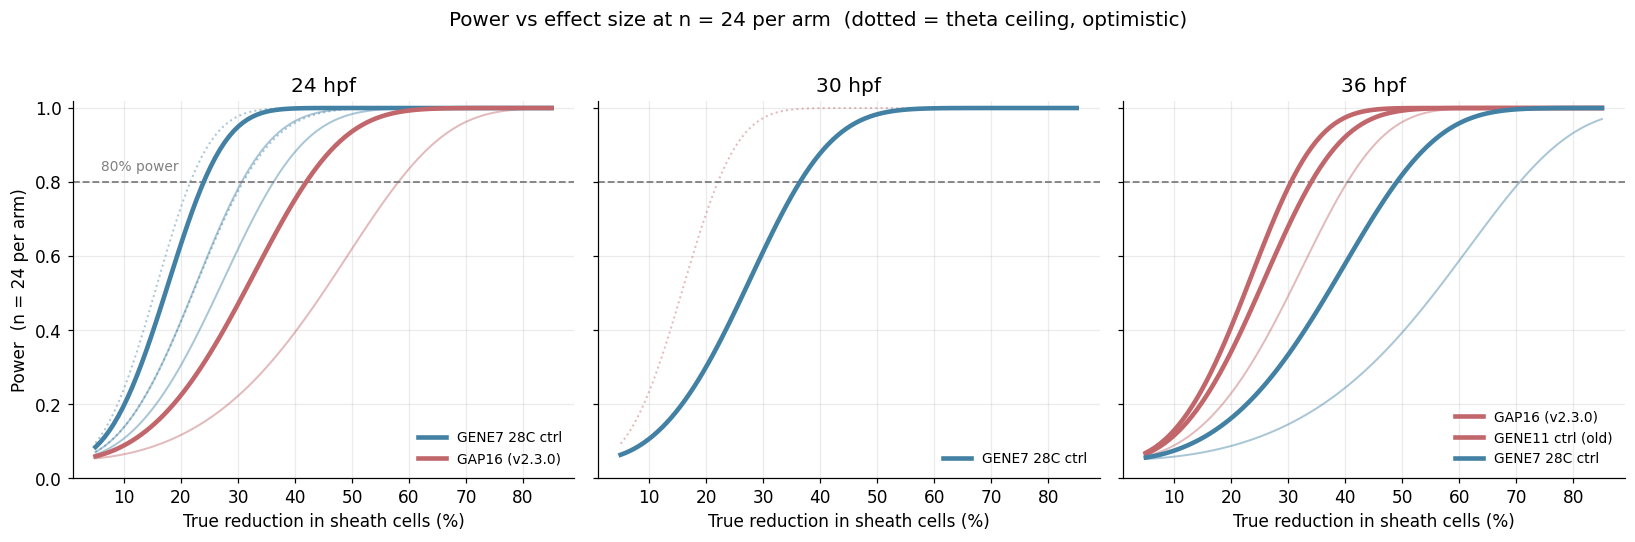

In [4]:
effects = np.linspace(0.05, 0.85, 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, stage in zip(axes, PANEL):
    rows = [r for r in records if r["hpf"] == stage]
    for r in sorted(rows, key=lambda r: -r["std_expected_sheath"]):
        pw = [sp.nb_power(r["theta"], r["rate"], r["standard_depth"], N_ARM, e) for e in effects]
        focus = r["dataset"] in FOCUS
        ax.plot(effects * 100, pw, color=colour(r["dataset"]),
                lw=3.0 if focus else 1.3,
                ls=":" if r["theta_is_ceiling"] else "-",
                alpha=1.0 if focus else 0.45, zorder=3 if focus else 2,
                label=r["dataset"] if focus else None)
    ax.axhline(0.80, ls="--", c="grey", lw=1.2)
    ax.set_title(f"{stage} hpf")
    ax.set_xlabel("True reduction in sheath cells (%)")
    ax.set_ylim(0, 1.02)
    if stage == PANEL[0]:
        ax.set_ylabel(f"Power  (n = {N_ARM} per arm)")
    ax.legend(frameon=False, fontsize=9, loc="lower right")

axes[0].text(6, 0.83, "80% power", fontsize=9, color="grey")
fig.suptitle(f"Power vs effect size at n = {N_ARM} per arm  (dotted = theta ceiling, optimistic)",
             y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Minimum detectable effect — the decision table as a picture

Smallest reduction detectable at 80% power with n = 24 per arm, **at the common
standardized depth**. **Shorter bars are better.** Bars past the right edge mean no
effect below 95% is detectable.

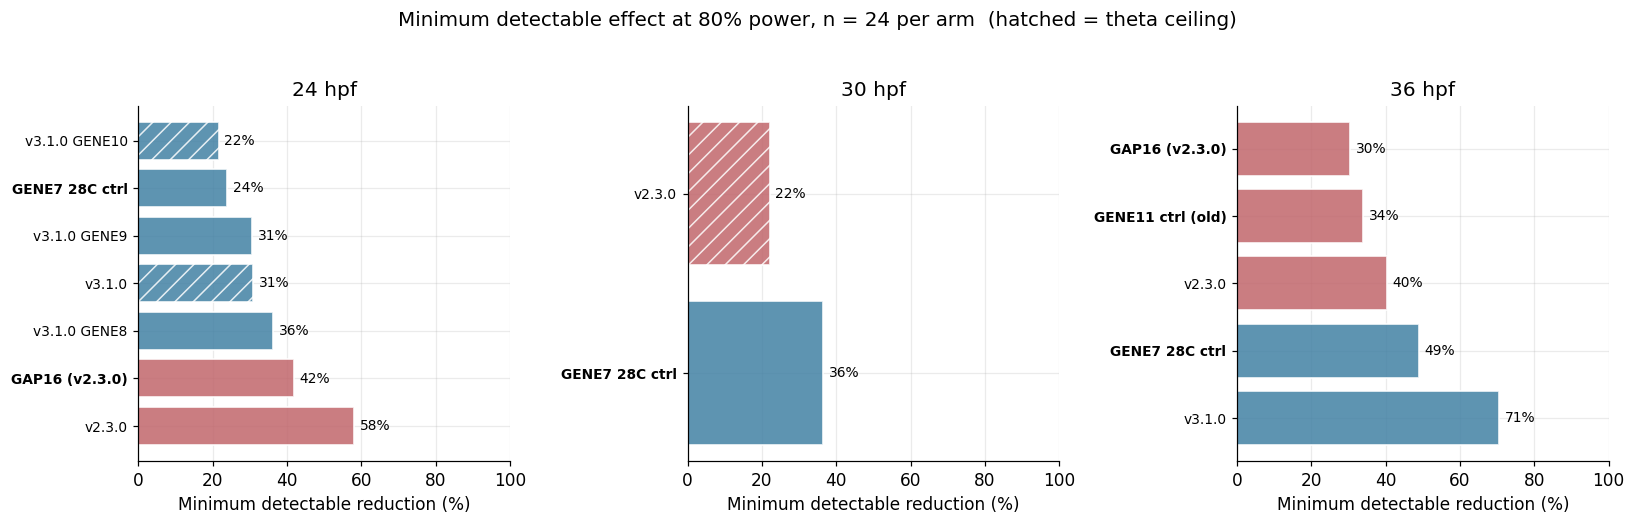

In [5]:
fig, axes = plt.subplots(1, len(PANEL), figsize=(15, 4.6), sharex=True)

for ax, stage in zip(axes, PANEL):
    rows = sorted([r for r in records if r["hpf"] == stage],
                  key=lambda r: (sp.mde(r["theta"], r["rate"], r["standard_depth"], N_ARM) or 1.0))
    names, vals, cols, hatches = [], [], [], []
    for r in rows:
        m = sp.mde(r["theta"], r["rate"], r["standard_depth"], N_ARM)
        names.append(r["dataset"])
        vals.append(100 * (m if m else 1.0))
        cols.append(colour(r["dataset"]))
        hatches.append("//" if r["theta_is_ceiling"] else "")
    y = np.arange(len(names))
    bars = ax.barh(y, vals, color=cols, alpha=0.85,
                   edgecolor="white", linewidth=1.2)
    for b, h in zip(bars, hatches):
        b.set_hatch(h)
    for yi, (v, r) in enumerate(zip(vals, rows)):
        lbl = f"{v:.0f}%" if sp.mde(r["theta"], r["rate"], r["standard_depth"], N_ARM) else ">95%"
        ax.text(v + 1.5, yi, lbl, va="center", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels([n.replace(" run 1", "") for n in names], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("Minimum detectable reduction (%)")
    ax.set_title(f"{stage} hpf")
    for r, yi in zip(rows, y):
        if r["dataset"] in FOCUS:
            ax.get_yticklabels()[yi].set_fontweight("bold")

fig.suptitle(f"Minimum detectable effect at 80% power, n = {N_ARM} per arm  (hatched = theta ceiling)",
             y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

## 5. Why 36 hpf behaves the way it does

Splitting the log-rate variance into its Poisson part (`1/mu`, shrinks with deeper
sequencing) and its overdispersion part (`1/theta`, does **not**). Where the orange
segment dominates, the configuration is dispersion-limited and more sequencing will
not help.

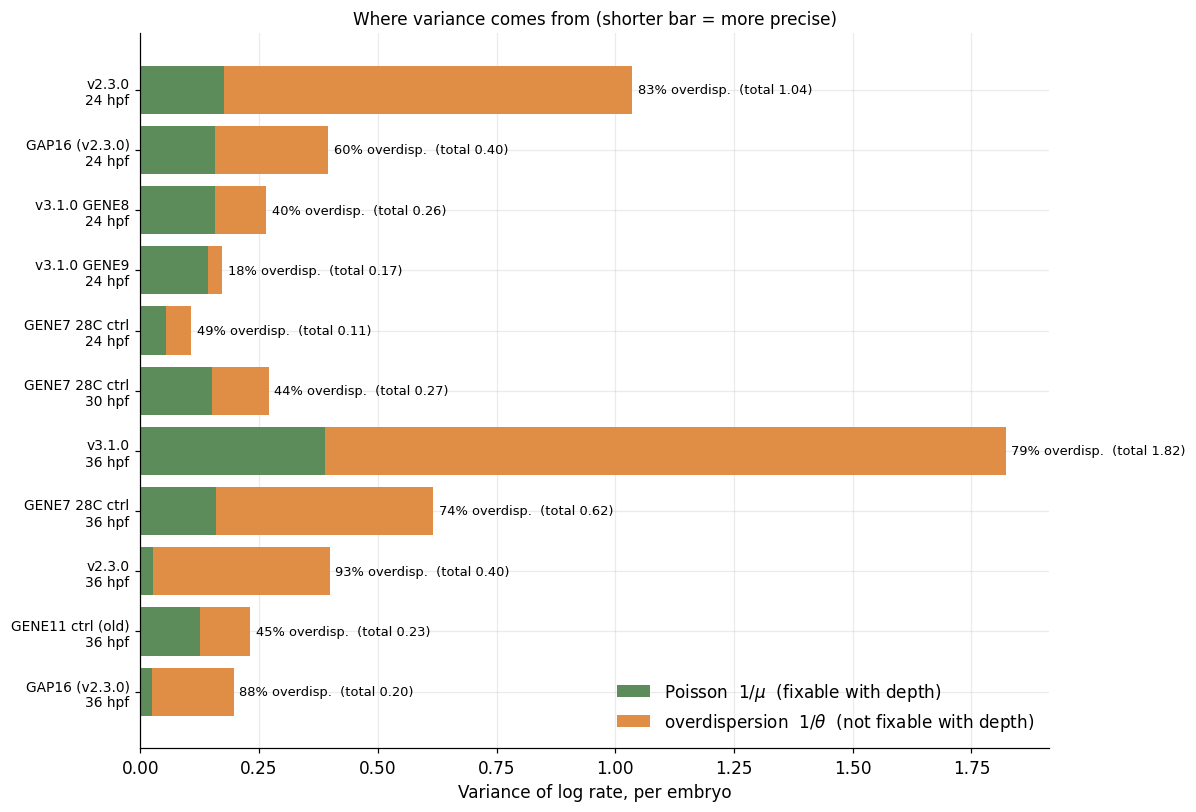

In [6]:
rows = [r for r in records if not r["theta_is_ceiling"]]
rows.sort(key=lambda r: (r["hpf"], -(sp.variance_split(r)[0] + sp.variance_split(r)[1])))

labels, pois, over = [], [], []
for r in rows:
    p, o, _ = sp.variance_split(r)
    labels.append(f"{r['dataset'].replace(' run 1','')}\n{r['hpf']:.0f} hpf")
    pois.append(p); over.append(o)

y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 0.52 * len(labels) + 1.8))
ax.barh(y, pois, color="#5B8C5A", label="Poisson  $1/\\mu$  (fixable with depth)")
ax.barh(y, over, left=pois, color="#E08E45", label="overdispersion  $1/\\theta$  (not fixable with depth)")
for yi, (p, o) in enumerate(zip(pois, over)):
    frac = o / (p + o)
    ax.text(p + o + 0.012, yi, f"{100*frac:.0f}% overdisp.  (total {p+o:.2f})",
            va="center", fontsize=8.5)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Variance of log rate, per embryo")
ax.legend(frameon=False, loc="lower right")
ax.set_title("Where variance comes from (shorter bar = more precise)", fontsize=11)
fig.tight_layout()
plt.show()

## 6. Per-embryo distributions

The summary statistics rest on small groups in several cases, so here are the actual
per-embryo sheath counts. Wide, heavy-tailed distributions are what produce low `theta`.

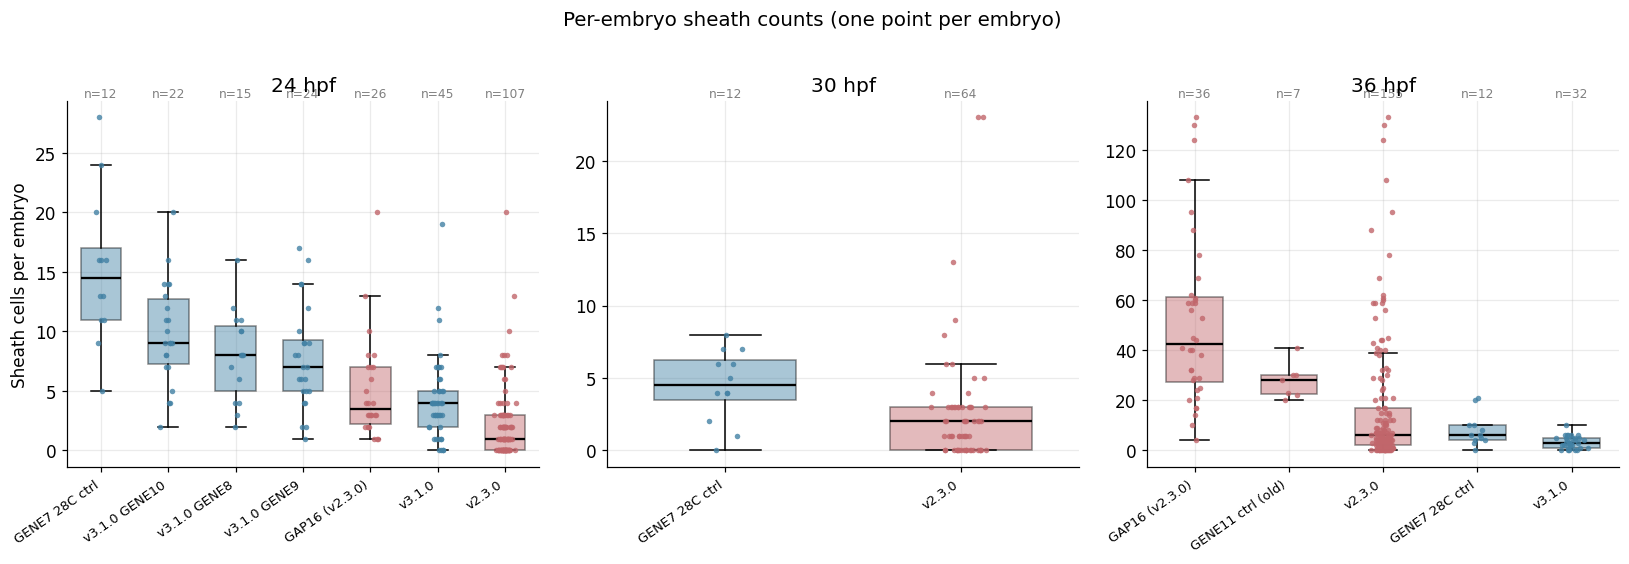

In [7]:
fig, axes = plt.subplots(1, len(PANEL), figsize=(15, 5), sharey=False)

for ax, stage in zip(axes, PANEL):
    rows = sorted([r for r in records if r["hpf"] == stage], key=lambda r: -r["mean_sheath"])
    data = [r["sheath_counts"] for r in rows]
    names = [r["dataset"].replace(" run 1", "") for r in rows]
    bp = ax.boxplot(data, vert=True, patch_artist=True, showfliers=False,
                    widths=0.6, medianprops=dict(color="black", lw=1.5))
    for patch, r in zip(bp["boxes"], rows):
        patch.set_facecolor(colour(r["dataset"])); patch.set_alpha(0.45)
    rng = np.random.default_rng(0)
    for i, (d, r) in enumerate(zip(data, rows), start=1):
        ax.scatter(i + rng.normal(0, 0.055, len(d)), d, s=13,
                   color=colour(r["dataset"]), alpha=0.8, zorder=3, linewidths=0)
    for i, r in enumerate(rows, start=1):
        ax.text(i, ax.get_ylim()[1], f"n={r['n_embryos']}", ha="center",
                va="bottom", fontsize=8, color="grey")
    ax.set_xticks(range(1, len(names) + 1))
    ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8.5)
    ax.set_title(f"{stage} hpf")
    if stage == PANEL[0]:
        ax.set_ylabel("Sheath cells per embryo")

fig.suptitle("Per-embryo sheath counts (one point per embryo)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 6b. Focused count comparison: GENE7 vs GAP16 vs GENE11 vs GENE10

The four datasets most relevant to the decision, showing **raw sheath cells per
embryo** (left) and **sheath cells per 1,000 recovered cells** (right) at each panel
timepoint. Total library depth is deliberately *not* shown here — it is a
sequencing-time choice, not a factor in the protocol decision. Per-1,000 is the
depth-neutral abundance; raw count is what the deep-sequenced datasets actually
delivered. Coverage is uneven (GENE10 is 24 hpf only; GENE11 is 36 hpf only; GAP16
has no 30 hpf), so empty slots are genuinely missing data.

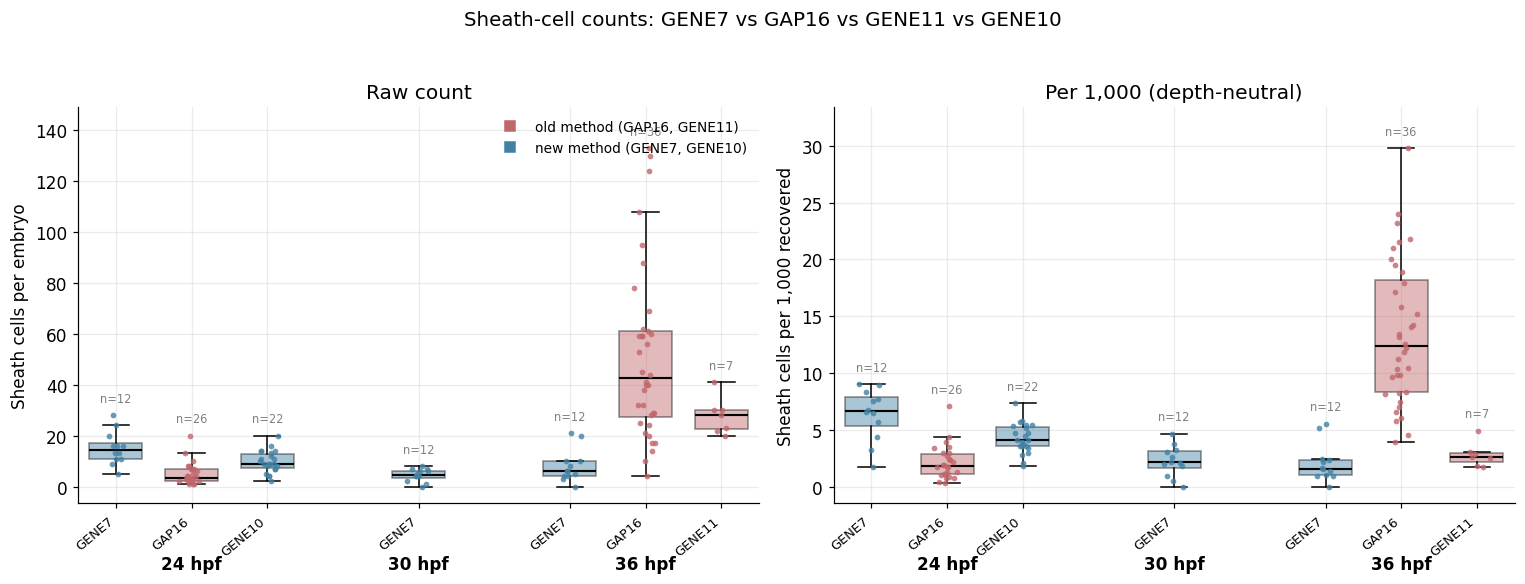

In [8]:
COUNT_SETS = ["GENE7 28C ctrl", "GAP16 (v2.3.0)", "GENE11 ctrl (old)", "v3.1.0 GENE10 run 1"]
short = {"GENE7 28C ctrl": "GENE7", "GAP16 (v2.3.0)": "GAP16",
         "GENE11 ctrl (old)": "GENE11", "v3.1.0 GENE10 run 1": "GENE10"}
cset_col = {"GENE7 28C ctrl": COL_NEW, "v3.1.0 GENE10 run 1": COL_NEW,
            "GAP16 (v2.3.0)": COL_OLD, "GENE11 ctrl (old)": COL_OLD}

by = {(r["dataset"], r["hpf"]): r for r in records}
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, mode in zip(axes, ["raw", "per1000"]):
    positions, data, cols, ticklabels = [], [], [], []
    pos = 0
    group_centers, group_labels = [], []
    for stage in PANEL:
        present = [(ds, by[(ds, stage)]) for ds in COUNT_SETS if (ds, stage) in by]
        if not present:
            continue
        start = pos
        for ds, r in present:
            if mode == "raw":
                vals = r["sheath_counts"]
            else:
                vals = [1000 * sc / tc for sc, tc in zip(r["sheath_counts"], r["total_counts"])]
            positions.append(pos)
            data.append(vals)
            cols.append(cset_col[ds])
            ticklabels.append(short[ds])
            pos += 1
        group_centers.append((start + pos - 1) / 2)
        group_labels.append(f"{stage:.0f} hpf")
        pos += 1  # gap between timepoint groups

    bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True,
                    showfliers=False, medianprops=dict(color="black", lw=1.4))
    for patch, c in zip(bp["boxes"], cols):
        patch.set_facecolor(c); patch.set_alpha(0.45)
    for p, vals, c in zip(positions, data, cols):
        ax.scatter(p + rng.normal(0, 0.07, len(vals)), vals, s=14, color=c,
                   alpha=0.8, zorder=3, linewidths=0)
    ymax = max((max(v) for v in data if v), default=1)
    for p, vals in zip(positions, data):
        top = max(vals) if vals else 0
        ax.text(p, top + 0.03 * ymax, f"n={len(vals)}", ha="center", va="bottom",
                fontsize=7.5, color="grey")
    ax.set_ylim(top=ymax * 1.12)

    ax.set_xticks(positions)
    ax.set_xticklabels(ticklabels, rotation=40, ha="right", fontsize=8.5)
    for c, lab in zip(group_centers, group_labels):
        ax.text(c, -0.13, lab, transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=11, weight="bold")
    ax.set_ylabel("Sheath cells per embryo" if mode == "raw"
                  else "Sheath cells per 1,000 recovered")
    ax.set_title("Raw count" if mode == "raw" else "Per 1,000 (depth-neutral)")

handles = [Line2D([], [], marker="s", ls="", color=COL_OLD, label="old method (GAP16, GENE11)"),
           Line2D([], [], marker="s", ls="", color=COL_NEW, label="new method (GENE7, GENE10)")]
axes[0].legend(handles=handles, frameon=False, loc="upper right", fontsize=9)
fig.suptitle("Sheath-cell counts: GENE7 vs GAP16 vs GENE11 vs GENE10", y=1.02, fontsize=13)
fig.subplots_adjust(bottom=0.20)
fig.tight_layout(rect=[0, 0.04, 1, 0.99])
plt.show()

## 7. Sample-size curves for the two candidate protocols

Power at a 40% reduction as a function of per-arm n, restricted to the two
configurations the decision rests on. The old protocol has no GAP16-quality run at
30 hpf, so that panel falls back to pooled v2.3.0 (median depth ~612 cells) and almost
certainly *understates* what a GAP16-equivalent 30 hpf collection would achieve.

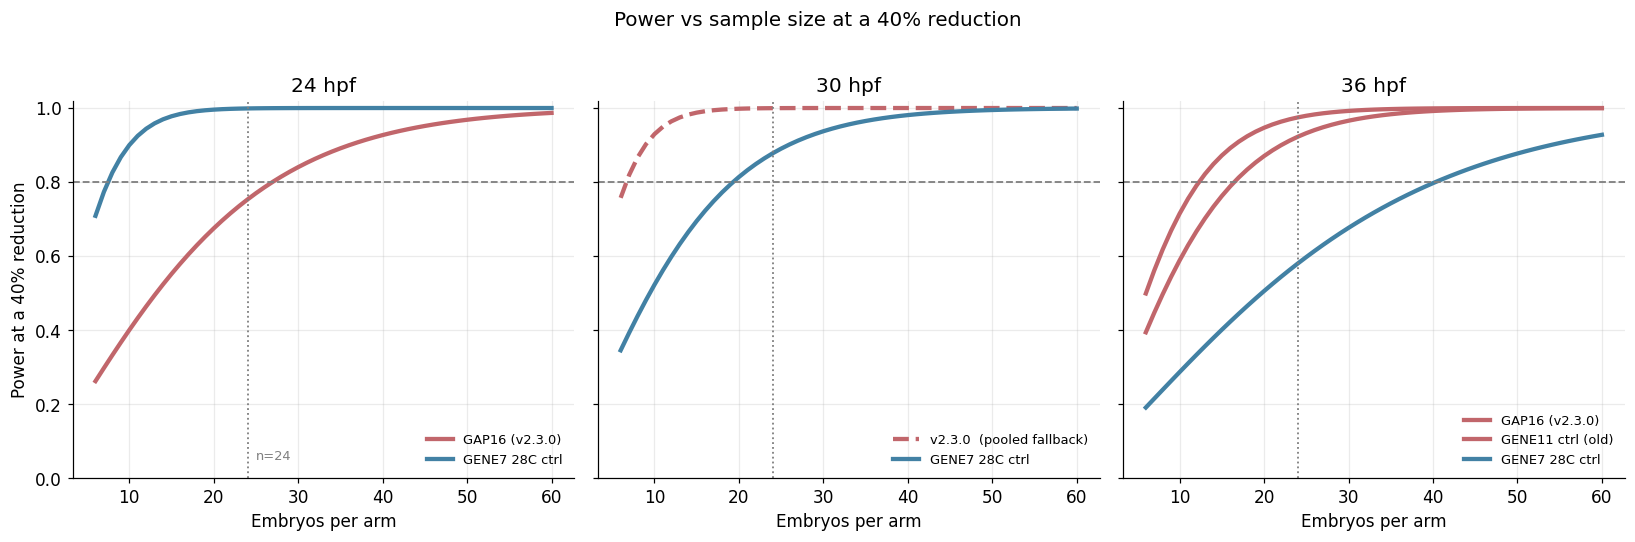

In [9]:
ns = np.arange(6, 61, 1)
fig, axes = plt.subplots(1, len(PANEL), figsize=(15, 4.8), sharey=True)

pick = {24: ["GAP16 (v2.3.0)", "GENE7 28C ctrl"],
        30: ["v2.3.0", "GENE7 28C ctrl"],
        36: ["GAP16 (v2.3.0)", "GENE11 ctrl (old)", "GENE7 28C ctrl"]}

for ax, stage in zip(axes, PANEL):
    for name in pick[stage]:
        match = [r for r in records if r["dataset"] == name and r["hpf"] == stage]
        if not match:
            continue
        r = match[0]
        pw = [sp.nb_power(r["theta"], r["rate"], r["standard_depth"], int(n), EFFECT) for n in ns]
        lbl = name + ("  (pooled fallback)" if stage == 30 and name == "v2.3.0" else "")
        ax.plot(ns, pw, color=colour(name), lw=2.8,
                ls="--" if (stage == 30 and name == "v2.3.0") else "-", label=lbl)
    ax.axhline(0.80, ls="--", c="grey", lw=1.2)
    ax.axvline(N_ARM, ls=":", c="grey", lw=1.2)
    ax.set_title(f"{stage} hpf")
    ax.set_xlabel("Embryos per arm")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    if stage == PANEL[0]:
        ax.set_ylabel(f"Power at a {EFFECT:.0%} reduction")

axes[0].text(N_ARM + 1, 0.05, f"n={N_ARM}", fontsize=8.5, color="grey")
fig.suptitle(f"Power vs sample size at a {EFFECT:.0%} reduction", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

## 8. Numbers behind the plots

In [10]:
hdr = (f"{'dataset':22s} {'hpf':>4s} {'n':>4s} {'obsDep':>7s} {'per1k':>6s} "
       f"{'theta':>7s} {'stdSh':>6s} | {'pw30':>5s} {'pw40':>5s} {'pw50':>5s} | {'MDE80':>6s}")
print(f"per-arm n = {N_ARM};  all power at standardized depth = {STD_DEPTH} cells/embryo")
print(f"stdSh = expected sheath at that depth (= per1k/1000 * {STD_DEPTH}); obsDep = native depth, shown for reference\n")
print(hdr); print("-" * len(hdr))
for r in records:
    th = "  inf*" if r["theta_is_ceiling"] else f"{r['theta']:7.2f}"
    pw = [sp.std_power(r, N_ARM, e) for e in (0.30, 0.40, 0.50)]
    m = sp.std_mde(r, N_ARM)
    ms = f"{100*m:5.1f}%" if m else "  >95%"
    print(f"{r['dataset']:22s} {r['hpf']:4.0f} {r['n_embryos']:4d} {r['median_depth']:7.0f} "
          f"{r['per_1000']:6.2f} {th} {r['std_expected_sheath']:6.1f} | "
          f"{pw[0]:5.2f} {pw[1]:5.2f} {pw[2]:5.2f} | {ms:>6s}")
print("\n* theta below Poisson (small-n artifact); power figures are optimistic ceilings.")

per-arm n = 24;  all power at standardized depth = 3000 cells/embryo
stdSh = expected sheath at that depth (= per1k/1000 * 3000); obsDep = native depth, shown for reference

dataset                 hpf    n  obsDep  per1k   theta  stdSh |  pw30  pw40  pw50 |  MDE80
-------------------------------------------------------------------------------------------
GENE7 28C ctrl           24   12    2362   6.19   19.06   18.6 |  0.95  1.00  1.00 |  24.0%
v3.1.0 GENE10 run 1      24   22    2521   4.18   inf*   12.5 |  0.98  1.00  1.00 |  21.6%
v3.1.0 GENE9 run 1       24   24    3435   2.34   32.97    7.0 |  0.78  0.96  1.00 |  30.6%
GAP16 (v2.3.0)           24   26    2440   2.13    4.18    6.4 |  0.47  0.75  0.94 |  42.0%
v3.1.0 GENE8 run 1       24   15    4022   2.11    9.39    6.3 |  0.62  0.88  0.98 |  36.2%
v3.1.0                   24   45    2114   1.95   inf*    5.9 |  0.77  0.96  1.00 |  30.9%
v2.3.0                   24  107     822   1.89    1.16    5.7 |  0.22  0.39  0.62 |  58.1%


## 9. Why standardizing to a fixed depth is safe

Power vs *absolute* depth (cells/embryo), with the chosen `STD_DEPTH` marked. Depth
enters only through the Poisson term `1/mu`; once `mu` is large the overdispersion
term `1/theta` dominates and the curve flattens. Where a config sits on the flat
part, the exact value of STD_DEPTH barely matters — which is what makes the
standardized comparison robust to the specific number chosen.

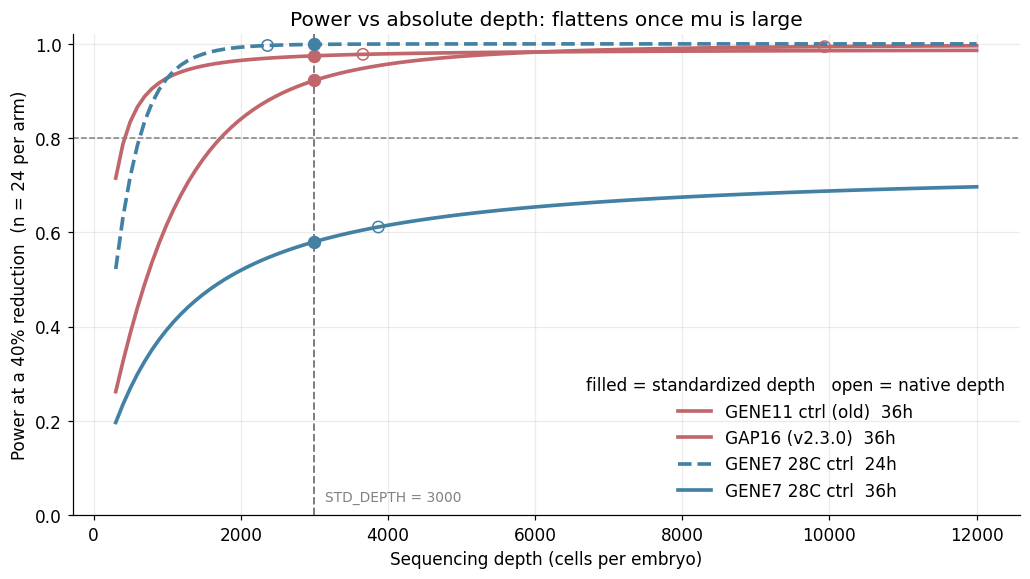

In [11]:
depths = np.linspace(300, 12000, 120)
fig, ax = plt.subplots(figsize=(9.5, 5.4))

depth_focus = [("GENE11 ctrl (old)", 36.0), ("GAP16 (v2.3.0)", 36.0),
               ("GENE7 28C ctrl", 24.0), ("GENE7 28C ctrl", 36.0)]
by = {(r["dataset"], r["hpf"]): r for r in records}
for key in depth_focus:
    if key not in by:
        continue
    r = by[key]
    pw = [sp.nb_power(r["theta"], r["rate"], d, N_ARM, EFFECT) for d in depths]
    ax.plot(depths, pw, lw=2.4, color=colour(r["dataset"]),
            ls="-" if r["hpf"] == 36 else "--",
            label=f"{r['dataset'].replace(' run 1','')}  {r['hpf']:.0f}h")
    # native depth marker (open) and standardized depth marker (filled)
    ax.scatter([r["median_depth"]], [sp.nb_power(r["theta"], r["rate"], r["median_depth"], N_ARM, EFFECT)],
               facecolor="none", edgecolor=colour(r["dataset"]), s=55, zorder=5)
    ax.scatter([STD_DEPTH], [sp.std_power(r, N_ARM, EFFECT)],
               color=colour(r["dataset"]), s=60, zorder=6)

ax.axvline(STD_DEPTH, ls="--", c="grey", lw=1.3)
ax.axhline(0.80, ls="--", c="grey", lw=1.0)
ax.text(STD_DEPTH + 150, 0.03, f"STD_DEPTH = {STD_DEPTH}", fontsize=9, color="grey")
ax.set_xlabel("Sequencing depth (cells per embryo)")
ax.set_ylabel(f"Power at a {EFFECT:.0%} reduction  (n = {N_ARM} per arm)")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False, loc="lower right",
          title="filled = standardized depth   open = native depth")
ax.set_title("Power vs absolute depth: flattens once mu is large")
fig.tight_layout()
plt.show()

## What the plots say

All numbers below are **at the standardized depth (3000 cells/embryo)**, so they
compare abundance and dispersion only — sequencing depth has been divided out.

**The protocols fail in different places, and the crossover is between 24 and 36 hpf.**
At 24 hpf the new method is far better (GENE7: 18.6 expected sheath, MDE ~24% vs
GAP16's 6.4, MDE ~42%). At 36 hpf it reverses hard — GAP16 gives 42.1 expected sheath
(MDE ~30%, power 0.97 at a 40% cut) against GENE7's 6.3 (MDE ~49%, power 0.58).

**Standardizing depth changes one earlier conclusion: GENE11's 36 hpf edge was mostly
its very deep libraries.** At native depth (~9.9k cells) it looked like the top 36 hpf
config; at 3000 cells its low per-1,000 rate (2.6) drops expected sheath to 7.9 and
power to 0.92. Still solid, but GAP16 (per-1,000 = 14.0) is the clear 36 hpf leader
once depth is held fixed. This is exactly why depth was standardized.

**36 hpf under the new method is dispersion-limited** (panel 5): most of its variance is
overdispersion, which no amount of sequencing removes — so the standardized comparison
is the honest one, and more reads would not rescue it.

**Since protocol cannot vary across timepoints** without confounding protocol with
stage, the choice is one protocol for the whole panel. The old method is weakest at
24 hpf — where the phenotype is least resolved anyway — and strongest at 36 hpf, where
the phenotype is cleanest. That asymmetry favours it for this design.

**Open items.** GAP16's 24 hpf per-1,000 rate beats every other v2.3.0 experiment, so
some of its advantage may be GAP16-specific rather than generic to the old method.
And no GAP16-quality 30 hpf run exists in either protocol — that is the missing cell
in the table, not a stage where the assay is known to fail.